In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import tables_io
import matplotlib.pyplot as plt 
%matplotlib inline 


In [2]:
dir_wide_catalog = '../job/data/hlwas_cosmos_260120_UM_2026_01_22.parquet'
dir_output = '../job/out/'

In [3]:
widegalaxy = tables_io.read(dir_wide_catalog)
widegalaxy_assignment = tables_io.read(dir_output + 'widedata_wide_assignment.hdf5')
tomotbinwide = tables_io.read(dir_output + 'tomo_bins_wide.hdf5')
widebinning = tomotbinwide['tomo_bins_wide'][:,0][widegalaxy_assignment['cells']]
wzsample = tables_io.read(dir_output + 'photoz_realizations.hdf5')
tomotbinwide_ref = h5py.File(dir_output +'FINAL_NZ.hdf5','r')

column_list None


In [4]:
wzsamples = []
for keys in wzsample.keys():
    wzsamples.append(wzsample[keys])
wzsamples = np.concatenate(wzsamples, axis=0)    

In [5]:
redshiftcol='specz'
zbinsc = tomotbinwide_ref['meta/xvals'][:][0]

In [6]:
len(zbinsc)

101

6391
8677
9177
16389
6865


(0.0, 3.2)

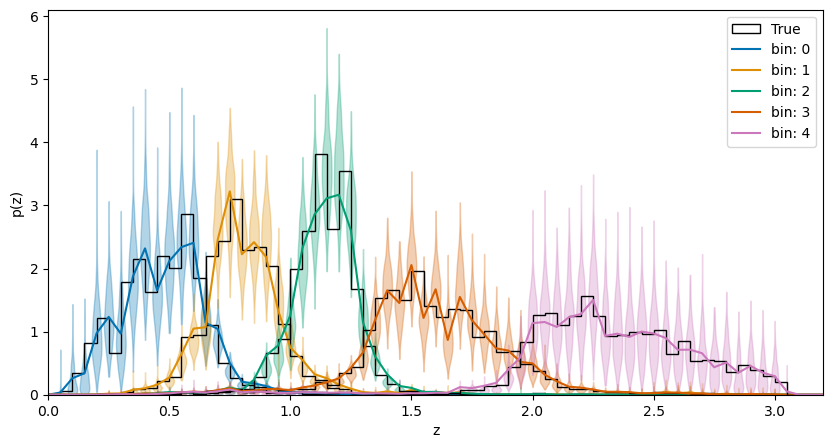

In [7]:
import seaborn as sns
colors = sns.color_palette('colorblind')
fig = plt.figure(figsize=(10,5))
for i in range(5):
    if i==0:
        name="True"
    else:
        name=None
    plt.hist(np.array(widegalaxy[redshiftcol])[widebinning==i], density=True, histtype="step", bins=zbinsc, color='k', label=name)
    print(len(np.array(widegalaxy[redshiftcol])[widebinning==i]))
    plt.plot(zbinsc,tomotbinwide_ref['data/yvals'][:][i], "-", label="bin: "+str(i), c=colors[i])
    violin_parts = plt.violinplot(wzsamples[:,i,:]/(zbinsc[1]-zbinsc[0]), positions=zbinsc, widths=0.04, showmeans=False, showmedians=False, showextrema=False, quantiles = None)
    for pc in violin_parts['bodies']:
        pc.set_facecolor(colors[i])
        pc.set_edgecolor(colors[i])
plt.legend()
plt.xlabel("z")
plt.ylabel("p(z)")
plt.xlim(0,3.2)
